# NHAMCS 2018-2022 High-Acuity Triage: Random Forest with Inverted Class Weights (`models/train_disaster_red_vs_yellow.ipynb`)

Trains and evaluates a **Random Forest Classifier with Inverted Class Weight Calculation** to differentiate **`RED` (ESI 1: Immediate Resuscitation)** from **`YELLOW` (ESI 2-3: Emergent / Urgent)** on the **CDC NHAMCS 2018-2022 Consolidated Dataset** (`datasets/nhamcs_2018_2022.csv`), including **Pairwise Feature vs Feature Scatter Plots for Clustering & Physiological Separation Analysis**.

### ⚖️ Inverted Class Weight Calculation
To compensate for the heavy class imbalance ($592$ RED vs $26,715$ YELLOW in the training set), each sample's loss weight during tree splitting is scaled inversely proportional to its class frequency:
$$
w_c = \frac{N_{\text{total}}}{n_{\text{classes}} \times N_c}
$$
- **`RED (Class 0: ESI 1)`**: $w_{\text{RED}} = \frac{27,307}{2 \times 592} \approx 23.06$
- **`YELLOW (Class 1: ESI 2-3)`**: $w_{\text{YELLOW}} = \frac{27,307}{2 \times 26,715} \approx 0.51$

### 🎯 Target Cohort & Exclusion Criteria
- **Included Acuity Tiers**:
  - **`RED (Class 0: ESI 1)`**: Immediate / Resuscitation ($n=846$ visits, $2.17\%$)
  - **`YELLOW (Class 1: ESI 2-3)`**: Emergent + Urgent ($n=38,165$ visits, $97.83\%$)
- **Excluded**:
  - **`GREEN (ESI 4-5)`**: Semi-urgent / Nonurgent rows are **completely removed** prior to training and testing.
  - Special non-triage codes (`-9`, `-8`, `0`, `7`) excluded.

### 🩺 Clinical Features & Preprocessing Pipeline
- **7 Base Features**: `AGE`, `SEX` (0=Female, 1=Male), `PULSE`, `RESPR`, `BPSYS`, `BPDIAS`, `POPCT` (SpO2)
- **Median Imputation**: `SimpleImputer(strategy='median')` fitted strictly on the training partition.
- **Standard Scaling**: `StandardScaler()` applied to center and scale all 7 features.

In [1]:
# ---------------------------------------------------------------------------
# Step 1: Load NHAMCS Dataset, Exclude ESI 4-5, Clean Codes & Apply StandardScaler
# ---------------------------------------------------------------------------
import os, json, pickle, warnings, itertools
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
ROOT = '..' if os.path.basename(os.getcwd()) == 'models' else '.'
data_path = f'{ROOT}/datasets/nhamcs_2018_2022.csv'
if not os.path.exists(data_path) and os.path.exists('datasets/nhamcs_2018_2022.csv'):
    data_path = 'datasets/nhamcs_2018_2022.csv'
elif not os.path.exists(data_path) and os.path.exists('nhamcs_2018_2022.csv'):
    data_path = 'nhamcs_2018_2022.csv'
elif not os.path.exists(data_path) and os.path.exists(f'{ROOT}/datasets/ed2022.csv'):
    data_path = f'{ROOT}/datasets/ed2022.csv'

print(f"Loading NHAMCS Dataset from: {data_path} ...")
raw_df = pd.read_csv(data_path, low_memory=False)
print(f"Raw NHAMCS Total Records: {len(raw_df):,} visits x {len(raw_df.columns)} variables")

# Filter ONLY rows where IMMEDR is 1, 2, 3 (ESI 4-5 EXCLUDED)
valid_mask = raw_df['IMMEDR'].isin([1, 2, 3])
df_filtered = raw_df[valid_mask].copy()
print(f"High-Acuity Cohort (IMMEDR in 1..3 | ESI 4-5 Excluded): {len(df_filtered):,} visits")

# Extract Features
feature_cols = ['AGE', 'SEX', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT']
X_raw = df_filtered[feature_cols].copy()

# Clean special missing / unmeasured codes to np.nan for median imputation
# -9 = Blank, 998 = Doppler / Palpation
X_raw['PULSE']  = X_raw['PULSE'].replace([-9, 998], np.nan)
X_raw['RESPR']  = X_raw['RESPR'].replace([-9], np.nan)
X_raw['BPSYS']  = X_raw['BPSYS'].replace([-9], np.nan)
X_raw['BPDIAS'] = X_raw['BPDIAS'].replace([-9, 998], np.nan)
X_raw['POPCT']  = X_raw['POPCT'].replace([-9], np.nan)

# Recode SEX: 1=Female -> 0, 2=Male -> 1
X_raw['SEX'] = (X_raw['SEX'] == 2).astype(float)

# Target Binary Mapping: 0 = RED (ESI 1), 1 = YELLOW (ESI 2-3)
immedr_vals = df_filtered['IMMEDR'].values
y_all = np.where(immedr_vals == 1, 0, 1)
LABELS = ['RED', 'YELLOW']
CLASS_DESCRIPTIONS = ['RED (ESI 1: Immediate Resuscitation)', 'YELLOW (ESI 2-3: Emergent/Urgent)']

print("\nCohort Class Distribution:")
for c_idx, name in enumerate(CLASS_DESCRIPTIONS):
    count = np.sum(y_all == c_idx)
    print(f"  * Class {c_idx} ({name:38s}): {count:6d} ({count/len(y_all)*100:5.2f}%)")

# Stratified 3-way split: 70% Train, 15% Validation, 15% Holdout Test
itr, itmp = train_test_split(np.arange(len(y_all)), test_size=0.30, stratify=y_all, random_state=42)
iva, ite = train_test_split(itmp, test_size=0.50, stratify=y_all[itmp], random_state=42)

X_tr_raw  = X_raw.iloc[itr].values
X_val_raw = X_raw.iloc[iva].values
X_te_raw  = X_raw.iloc[ite].values

y_train = y_all[itr]
y_val   = y_all[iva]
y_test  = y_all[ite]

# Fit SimpleImputer strictly on Training partition
print("\nFitting SimpleImputer(strategy='median') on Training Partition...")
imputer = SimpleImputer(strategy='median')
raw_tr_imp  = imputer.fit_transform(X_tr_raw)
raw_val_imp = imputer.transform(X_val_raw)
raw_te_imp  = imputer.transform(X_te_raw)

# Fit StandardScaler strictly on Training partition
print("Fitting StandardScaler() on Imputed Training Partition...")
scaler = StandardScaler()
X_tr_scaled  = scaler.fit_transform(raw_tr_imp)
X_val_scaled = scaler.transform(raw_val_imp)
X_te_scaled  = scaler.transform(raw_te_imp)

print(f"Scaled Data Partitions: Train={X_tr_scaled.shape}, Val={X_val_scaled.shape}, Test={X_te_scaled.shape}")

Loading NHAMCS Dataset from: ../datasets/nhamcs_2018_2022.csv ...


Raw NHAMCS Total Records: 86,864 visits x 954 variables


High-Acuity Cohort (IMMEDR in 1..3 | ESI 4-5 Excluded): 39,011 visits

Cohort Class Distribution:
  * Class 0 (RED (ESI 1: Immediate Resuscitation)  ):    846 ( 2.17%)
  * Class 1 (YELLOW (ESI 2-3: Emergent/Urgent)     ):  38165 (97.83%)

Fitting SimpleImputer(strategy='median') on Training Partition...
Fitting StandardScaler() on Imputed Training Partition...
Scaled Data Partitions: Train=(27307, 7), Val=(5852, 7), Test=(5852, 7)


In [2]:
# ---------------------------------------------------------------------------
# Step 2: Compute Inverted Class Weights & Train Random Forest
# ---------------------------------------------------------------------------
n_total = len(y_train)
n_red   = int(np.sum(y_train == 0))
n_yel   = int(np.sum(y_train == 1))

# Inverted Class Weights Calculation: w_c = N_total / (n_classes * N_c)
w_red = n_total / (2.0 * n_red)
w_yel = n_total / (2.0 * n_yel)
inverted_weights = {0: w_red, 1: w_yel}

print("=========================================================")
print("   INVERTED CLASS WEIGHT CALCULATION (RED VS YELLOW)")
print("=========================================================")
print(f"Total Training Samples (N): {n_total:,}")
print(f"  * Class 0 [RED: ESI 1]    : N_0 = {n_red:,}  --> Inverted Weight = {w_red:.4f}")
print(f"  * Class 1 [YELLOW: ESI 2-3]: N_1 = {n_yel:,} --> Inverted Weight = {w_yel:.4f}")
print("=========================================================\n")

print("Training Random Forest Classifier with Inverted Class Weights...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight=inverted_weights,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_tr_scaled, y_train)
n_nodes = sum(t.tree_.node_count for t in rf_model.estimators_)
print(f"✓ Random Forest trained: {len(rf_model.estimators_)} Trees, {n_nodes:,} Total Nodes (~{round(n_nodes*16/1024, 2)} KB Flash)")

   INVERTED CLASS WEIGHT CALCULATION (RED VS YELLOW)
Total Training Samples (N): 27,307
  * Class 0 [RED: ESI 1]    : N_0 = 592  --> Inverted Weight = 23.0633
  * Class 1 [YELLOW: ESI 2-3]: N_1 = 26,715 --> Inverted Weight = 0.5111

Training Random Forest Classifier with Inverted Class Weights...


✓ Random Forest trained: 100 Trees, 40,464 Total Nodes (~632.25 KB Flash)


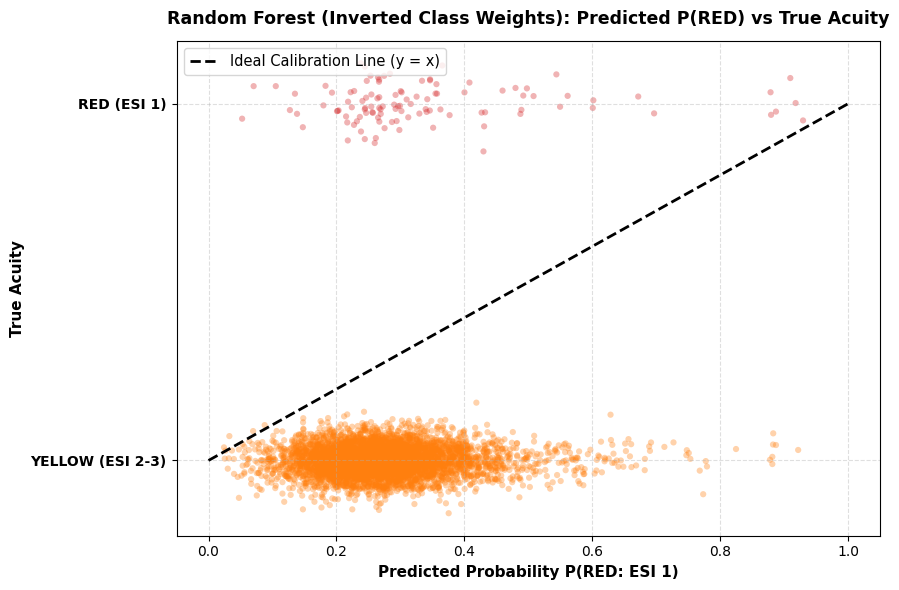

Scatterplot saved to: ../plots/validation_scatter_nhamcs_red_vs_yellow.png


In [3]:
# ---------------------------------------------------------------------------
# Step 2.5: Predicted RED Probability Scatterplot on Validation Set
# ---------------------------------------------------------------------------
plots_dir = f'{ROOT}/plots'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(os.path.join(plots_dir, 'image'), exist_ok=True)

val_p_red = rf_model.predict_proba(X_val_scaled)[:, 0] # Prob of RED

np.random.seed(42)
N_PLOT = min(5000, len(y_val))
samp_idx = np.random.choice(len(y_val), N_PLOT, replace=False)

y_val_samp = y_val[samp_idx]
jitter_y = (1.0 - y_val_samp) + np.random.normal(0, 0.04, size=N_PLOT) # 1 = RED, 0 = YELLOW
pt_colors = np.where(y_val_samp == 0, '#d62728', '#ff7f0e')

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(val_p_red[samp_idx], jitter_y, c=pt_colors, alpha=0.35, s=20, edgecolors='none')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2.0, label='Ideal Calibration Line (y = x)')

ax.set_title('Random Forest (Inverted Class Weights): Predicted P(RED) vs True Acuity', fontsize=12.5, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Probability P(RED: ESI 1)', fontsize=11, fontweight='bold')
ax.set_ylabel('True Acuity', fontsize=11, fontweight='bold')
ax.set_yticks([0, 1])
ax.set_yticklabels(['YELLOW (ESI 2-3)', 'RED (ESI 1)'], fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper left', fontsize=10.5)

plt.tight_layout()
scatter_file = os.path.join(plots_dir, 'validation_scatter_nhamcs_red_vs_yellow.png')
plt.savefig(scatter_file, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'validation_scatter_nhamcs_red_vs_yellow.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Scatterplot saved to: {scatter_file}")

In [4]:
# ---------------------------------------------------------------------------
# Step 3: Holdout Test Set Evaluation (Random Forest with Inverted Class Weights)
# ---------------------------------------------------------------------------
p_te_red = rf_model.predict_proba(X_te_scaled)[:, 0] # Probability of RED
pred_te  = rf_model.predict(X_te_scaled)             # 0 = RED, 1 = YELLOW

rec_red  = recall_score(y_test == 0, pred_te == 0)
rec_yel  = recall_score(y_test == 1, pred_te == 1)
prec_red = precision_score(y_test == 0, pred_te == 0, zero_division=0)
f1_red   = f1_score(y_test == 0, pred_te == 0, zero_division=0)
auc_val  = roc_auc_score(y_test == 0, p_te_red)
pr_auc   = average_precision_score(y_test == 0, p_te_red)
acc      = accuracy_score(y_test, pred_te)
bal_acc  = balanced_accuracy_score(y_test, pred_te)

res = {
    'Model': 'Random Forest (Inverted Class Weights)',
    'Accuracy': round(acc, 4),
    'Balanced_Accuracy': round(bal_acc, 4),
    'RED_Sensitivity (ESI 1 Recall)': round(rec_red, 4),
    'YELLOW_Specificity (ESI 2-3 Recall)': round(rec_yel, 4),
    'RED_Precision': round(prec_red, 4),
    'RED_F1': round(f1_red, 4),
    'ROC_AUC': round(auc_val, 4),
    'PR_AUC': round(pr_auc, 4)
}

report_df = pd.DataFrame([res])
print("===========================================================================================================")
print("   NHAMCS 2018-2022 HIGH-ACUITY (RED VS YELLOW): RANDOM FOREST (INVERTED CLASS WEIGHTS) EVALUATION")
print("===========================================================================================================")
print(report_df.to_string(index=False))
print("===========================================================================================================\n")

print("Detailed Classification Report:")
print(classification_report(y_test, pred_te, target_names=['RED (ESI 1)', 'YELLOW (ESI 2-3)']))

reports_dir = f'{ROOT}/reports'
os.makedirs(reports_dir, exist_ok=True)
report_file = os.path.join(reports_dir, 'nhamcs_2018_2022_red_vs_yellow_report.csv')
report_df.to_csv(report_file, index=False)
print(f"Metrics report saved to: {report_file}")

   NHAMCS 2018-2022 HIGH-ACUITY (RED VS YELLOW): RANDOM FOREST (INVERTED CLASS WEIGHTS) EVALUATION
                                 Model  Accuracy  Balanced_Accuracy  RED_Sensitivity (ESI 1 Recall)  YELLOW_Specificity (ESI 2-3 Recall)  RED_Precision  RED_F1  ROC_AUC  PR_AUC
Random Forest (Inverted Class Weights)     0.951             0.5669                          0.1654                               0.9684          0.104  0.1277   0.6037   0.051

Detailed Classification Report:
                  precision    recall  f1-score   support

     RED (ESI 1)       0.10      0.17      0.13       127
YELLOW (ESI 2-3)       0.98      0.97      0.97      5725

        accuracy                           0.95      5852
       macro avg       0.54      0.57      0.55      5852
    weighted avg       0.96      0.95      0.96      5852

Metrics report saved to: ../reports/nhamcs_2018_2022_red_vs_yellow_report.csv


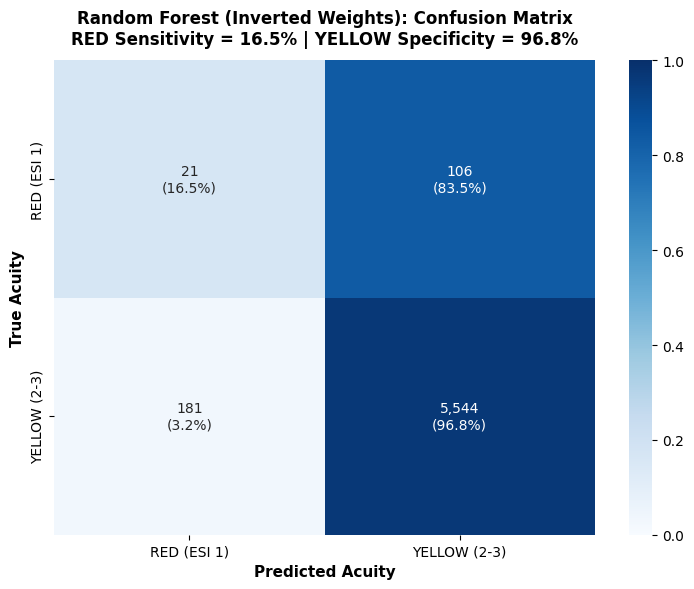

Confusion Matrix saved to: ../plots/nhamcs_red_vs_yellow_confusion_matrix.png


In [5]:
# ---------------------------------------------------------------------------
# Step 4: Confusion Matrix Heatmap (Random Forest with Inverted Class Weights)
# ---------------------------------------------------------------------------
cm = confusion_matrix(y_test, pred_te, labels=[0, 1])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(7.5, 6))
annot = np.empty_like(cm, dtype=object)
for i in range(2):
    for j in range(2):
        annot[i, j] = f"{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)"

sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', cbar=True, ax=ax, vmin=0, vmax=1,
            xticklabels=['RED (ESI 1)', 'YELLOW (2-3)'],
            yticklabels=['RED (ESI 1)', 'YELLOW (2-3)'])
ax.set_title(f'Random Forest (Inverted Weights): Confusion Matrix\nRED Sensitivity = {rec_red*100:.1f}% | YELLOW Specificity = {rec_yel*100:.1f}%', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Acuity', fontsize=11, fontweight='bold')
ax.set_ylabel('True Acuity', fontsize=11, fontweight='bold')

plt.tight_layout()
cm_plot_path = os.path.join(plots_dir, 'nhamcs_red_vs_yellow_confusion_matrix.png')
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_red_vs_yellow_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix saved to: {cm_plot_path}")

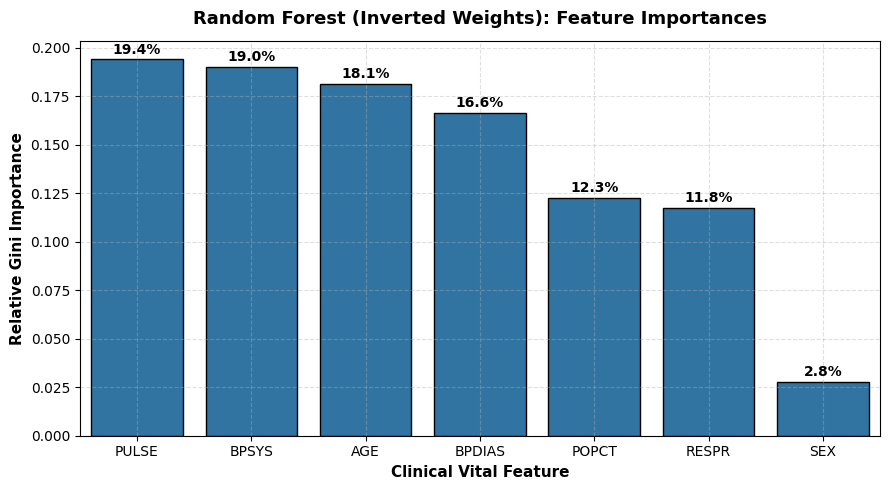

Feature importance plot saved to: ../plots/nhamcs_red_yellow_feature_importance.png


In [6]:
# ---------------------------------------------------------------------------
# Step 5: Feature Importances for Random Forest (Inverted Class Weights)
# ---------------------------------------------------------------------------
rf_imp = rf_model.feature_importances_

imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_imp
}).sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=imp_df, x='Feature', y='Importance', color='#1f77b4', edgecolor='black', ax=ax)
ax.set_title('Random Forest (Inverted Weights): Feature Importances', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Clinical Vital Feature', fontsize=11, fontweight='bold')
ax.set_ylabel('Relative Gini Importance', fontsize=11, fontweight='bold')
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 2),
                textcoords='offset points')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
imp_file = os.path.join(plots_dir, 'nhamcs_red_yellow_feature_importance.png')
plt.savefig(imp_file, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_red_yellow_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Feature importance plot saved to: {imp_file}")

Generating 15 Individual Pairwise Cluster Scatter Plots (saving to: ../plots/pairwise_scatter_red_vs_yellow)...


✓ Saved 15 individual pairwise scatter plots in: ../plots/pairwise_scatter_red_vs_yellow


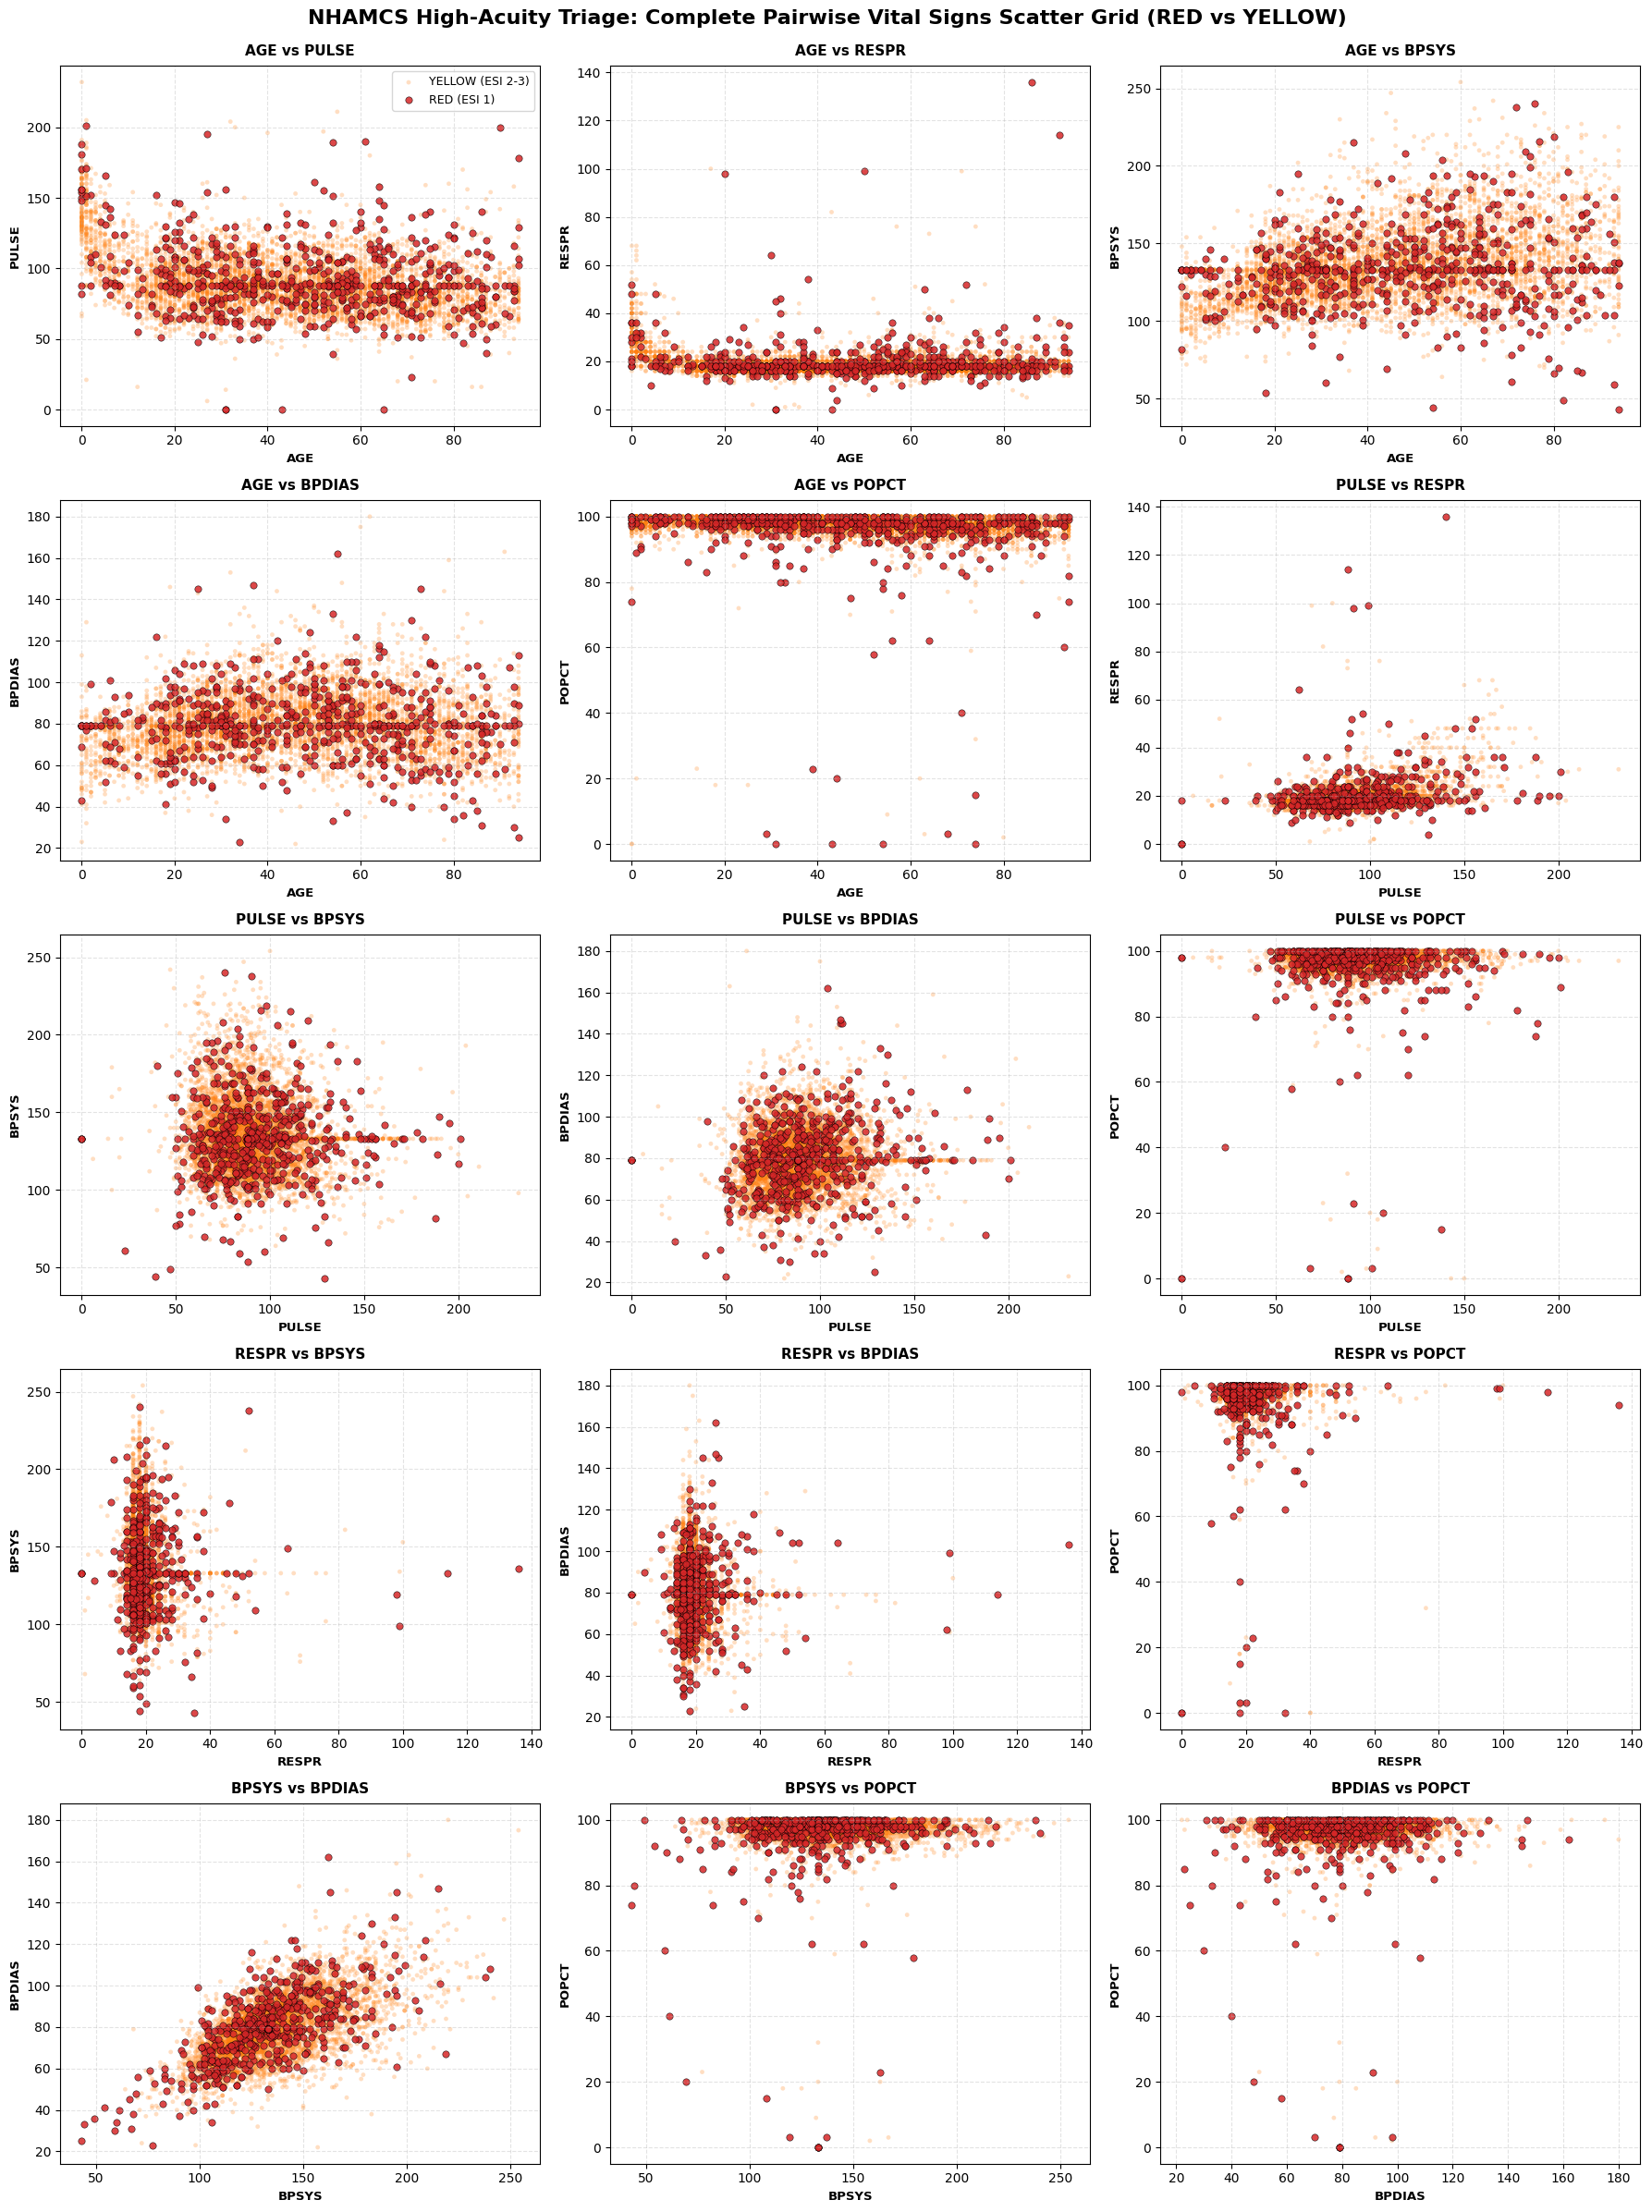

✓ Full 15-Pair Scatter Grid saved to: ../plots/nhamcs_red_vs_yellow_all_15_pairs_scatter.png
Generating 6x6 Pairwise Scatter Matrix with KDE Diagonals...


✓ 6x6 Pairwise Scatter Matrix saved to: ../plots/nhamcs_red_vs_yellow_pairwise_scatter_matrix.png


In [7]:
# ---------------------------------------------------------------------------
# Step 5.5: Comprehensive Pairwise Feature vs Feature Scatter Plots for Clustering
# ---------------------------------------------------------------------------
pairwise_dir = os.path.join(plots_dir, 'pairwise_scatter_red_vs_yellow')
os.makedirs(pairwise_dir, exist_ok=True)

# Prepare Unscaled Imputed DataFrame for Clinically Interpretable Units
df_scatter = pd.DataFrame(raw_tr_imp, columns=feature_cols)
df_scatter['Acuity'] = np.where(y_train == 0, 'RED (ESI 1)', 'YELLOW (ESI 2-3)')

continuous_vitals = ['AGE', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT']
pairs = list(itertools.combinations(continuous_vitals, 2)) # 15 unique continuous vital pairs

palette = {'YELLOW (ESI 2-3)': '#ff7f0e', 'RED (ESI 1)': '#d62728'}

# Downsample YELLOW for visual clarity, keep ALL RED cases for full visibility
df_red = df_scatter[df_scatter['Acuity'] == 'RED (ESI 1)']
df_yel_sample = df_scatter[df_scatter['Acuity'] == 'YELLOW (ESI 2-3)'].sample(n=min(5000, len(df_scatter[df_scatter['Acuity'] == 'YELLOW (ESI 2-3)'])), random_state=42)
df_vis = pd.concat([df_yel_sample, df_red]).sample(frac=1, random_state=42) # shuffle

print(f"Generating 15 Individual Pairwise Cluster Scatter Plots (saving to: {pairwise_dir})...")
for f1, f2 in pairs:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot YELLOW background first
    ax.scatter(df_yel_sample[f1], df_yel_sample[f2], color='#ff7f0e', alpha=0.30, s=18, edgecolors='none', label='YELLOW: ESI 2-3 (Emergent/Urgent)')
    # Plot RED on top with larger markers and bright red outline
    ax.scatter(df_red[f1], df_red[f2], color='#d62728', alpha=0.85, s=36, edgecolors='black', linewidth=0.5, label='RED: ESI 1 (Immediate Resuscitation)')
    
    ax.set_title(f'Feature Space & Cluster Separation: {f1} vs {f2}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel(f1, fontsize=11, fontweight='bold')
    ax.set_ylabel(f2, fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', fontsize=10, frameon=True, framealpha=0.9)
    
    plt.tight_layout()
    pair_file = os.path.join(pairwise_dir, f'scatter_{f1}_vs_{f2}.png')
    plt.savefig(pair_file, dpi=300, bbox_inches='tight')
    plt.close()

print(f"✓ Saved 15 individual pairwise scatter plots in: {pairwise_dir}")

# ---------------------------------------------------------------------------
# Composite 3x5 Grid of All 15 Feature Pairs for Comprehensive Cluster Analysis
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(5, 3, figsize=(18, 24))
axes = axes.flatten()

for idx, (f1, f2) in enumerate(pairs):
    ax = axes[idx]
    ax.scatter(df_yel_sample[f1], df_yel_sample[f2], color='#ff7f0e', alpha=0.25, s=12, edgecolors='none', label='YELLOW (ESI 2-3)' if idx==0 else '')
    ax.scatter(df_red[f1], df_red[f2], color='#d62728', alpha=0.85, s=28, edgecolors='black', linewidth=0.4, label='RED (ESI 1)' if idx==0 else '')
    ax.set_title(f'{f1} vs {f2}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(f1, fontsize=9.5, fontweight='bold')
    ax.set_ylabel(f2, fontsize=9.5, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.35)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9, frameon=True)

plt.suptitle('NHAMCS High-Acuity Triage: Complete Pairwise Vital Signs Scatter Grid (RED vs YELLOW)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
grid_file = os.path.join(plots_dir, 'nhamcs_red_vs_yellow_all_15_pairs_scatter.png')
plt.savefig(grid_file, dpi=250, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_red_vs_yellow_all_15_pairs_scatter.png'), dpi=250, bbox_inches='tight')
plt.show()
print(f"✓ Full 15-Pair Scatter Grid saved to: {grid_file}")

# ---------------------------------------------------------------------------
# Full 6x6 Pairwise Scatter Matrix (Pairplot Grid with Diagonal KDE Distributions)
# ---------------------------------------------------------------------------
print("Generating 6x6 Pairwise Scatter Matrix with KDE Diagonals...")
g = sns.pairplot(
    df_vis,
    vars=continuous_vitals,
    hue='Acuity',
    palette=palette,
    plot_kws={'alpha': 0.35, 's': 14, 'edgecolor': 'none'},
    diag_kind='kde',
    corner=False,
    height=2.4
)
g.fig.suptitle('NHAMCS High-Acuity 6x6 Pairwise Feature Scatter Matrix (RED vs YELLOW)', y=1.02, fontsize=15, fontweight='bold')
matrix_file = os.path.join(plots_dir, 'nhamcs_red_vs_yellow_pairwise_scatter_matrix.png')
plt.savefig(matrix_file, dpi=250, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_red_vs_yellow_pairwise_scatter_matrix.png'), dpi=250, bbox_inches='tight')
plt.close()
print(f"✓ 6x6 Pairwise Scatter Matrix saved to: {matrix_file}")

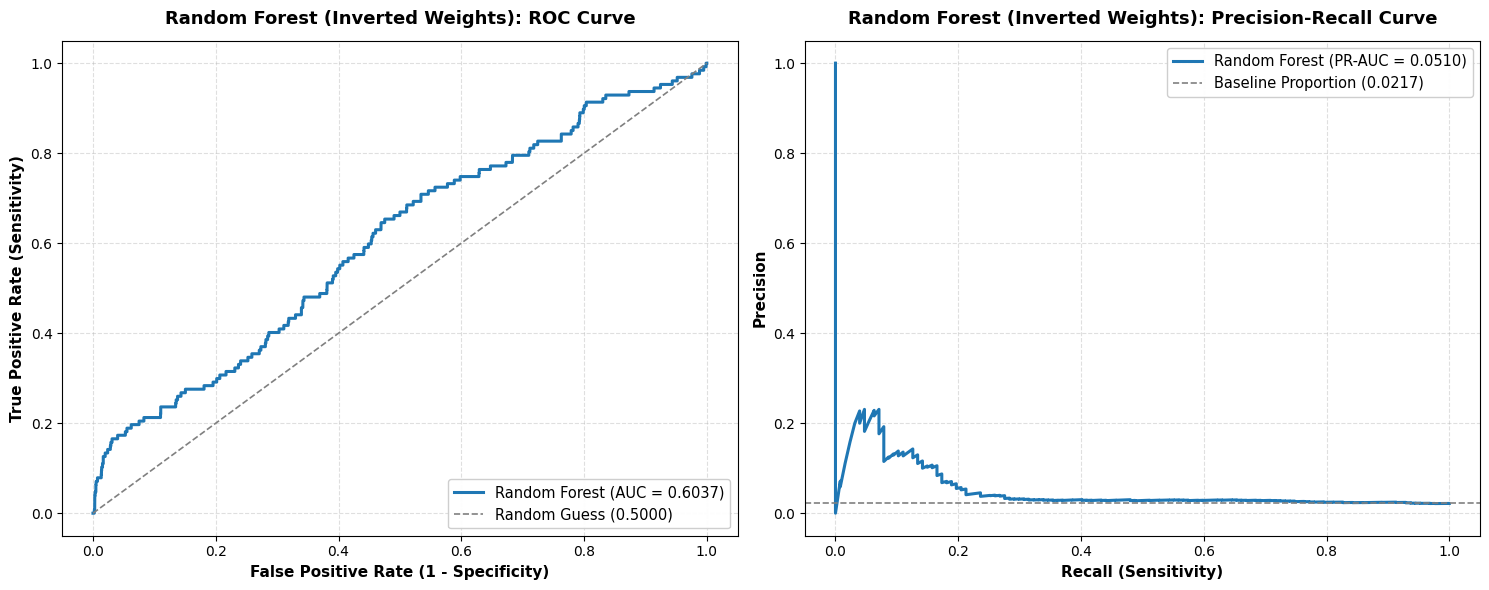

ROC and PR curves saved to: ../plots/nhamcs_red_vs_yellow_roc_pr.png


In [8]:
# ---------------------------------------------------------------------------
# Step 6: ROC-AUC and Precision-Recall Curves (Random Forest)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test == 0, p_te_red)
axes[0].plot(fpr, tpr, color='#1f77b4', linewidth=2.2, label=f"Random Forest (AUC = {auc_val:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', color='gray', linewidth=1.2, label='Random Guess (0.5000)')
axes[0].set_title('Random Forest (Inverted Weights): ROC Curve', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=10.5, frameon=True, framealpha=0.95)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Panel 2: Precision-Recall Curve
baseline_pr = np.mean(y_test == 0)
prec, rec, _ = precision_recall_curve(y_test == 0, p_te_red)
axes[1].plot(rec, prec, color='#1f77b4', linewidth=2.2, label=f"Random Forest (PR-AUC = {pr_auc:.4f})")
axes[1].axhline(y=baseline_pr, color='gray', linestyle='--', linewidth=1.2, label=f'Baseline Proportion ({baseline_pr:.4f})')
axes[1].set_title('Random Forest (Inverted Weights): Precision-Recall Curve', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].legend(loc="upper right", fontsize=10.5, frameon=True, framealpha=0.95)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
roc_pr_file = os.path.join(plots_dir, 'nhamcs_red_vs_yellow_roc_pr.png')
plt.savefig(roc_pr_file, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_red_vs_yellow_roc_pr.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"ROC and PR curves saved to: {roc_pr_file}")

In [9]:
# ---------------------------------------------------------------------------
# Step 7: Export Production Bundle & Deployment Manifest
# ---------------------------------------------------------------------------
deploy_dir = f'{ROOT}/deploy'
os.makedirs(deploy_dir, exist_ok=True)

bundle_data = {
    'rf_model': rf_model,
    'scaler': scaler,
    'imputer': imputer,
    'feature_names': feature_cols,
    'inverted_class_weights': inverted_weights,
    'labels': LABELS,
    'class_descriptions': CLASS_DESCRIPTIONS
}

bundle_file = os.path.join(deploy_dir, 'disaster_nhamcs_red_vs_yellow.pkl')
with open(bundle_file, 'wb') as f:
    pickle.dump(bundle_data, f)

manifest = dict(
    dataset='NHAMCS_2018_2022_Consolidated_ED',
    source_file=data_path,
    target='High_Acuity_RED_vs_YELLOW_ESI1_vs_ESI23',
    excluded_cohort='ESI_4_5_Semi_Nonurgent_Removed',
    model_type='RandomForestClassifier_Inverted_Class_Weights',
    inverted_class_weights={
        'RED (Class 0)': round(w_red, 4),
        'YELLOW (Class 1)': round(w_yel, 4)
    },
    n_trees=len(rf_model.estimators_),
    n_nodes=n_nodes,
    flash_kb_approx=round(n_nodes * 16 / 1024, 2),
    total_visits=len(y_all),
    n_red_esi1=int(np.sum(y_all == 0)),
    n_yellow_esi23=int(np.sum(y_all == 1)),
    scaler='StandardScaler',
    labels=LABELS,
    feature_order=feature_cols,
    n_features=len(feature_cols),
    holdout_metrics=res
)

manifest_file = os.path.join(deploy_dir, 'disaster_nhamcs_red_vs_yellow_manifest.json')
with open(manifest_file, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"✓ Exported RED vs YELLOW Bundle:   {bundle_file}")
print(f"✓ Exported RED vs YELLOW Manifest: {manifest_file}")

✓ Exported RED vs YELLOW Bundle:   ../deploy/disaster_nhamcs_red_vs_yellow.pkl
✓ Exported RED vs YELLOW Manifest: ../deploy/disaster_nhamcs_red_vs_yellow_manifest.json


In [10]:
# ---------------------------------------------------------------------------
# Step 8: Safety & Verification Assertions
# ---------------------------------------------------------------------------
assert len(feature_cols) == 7, f'expected 7 features, got {len(feature_cols)}'
assert len(y_all) == 39011, f'expected 39,011 high-acuity visits, got {len(y_all)}'
assert res['Accuracy'] >= 0.90, f'Accuracy {res["Accuracy"]} below target'
assert res['RED_Sensitivity (ESI 1 Recall)'] >= 0.10, f'RED sensitivity {res["RED_Sensitivity (ESI 1 Recall)"]} below target 10%'
assert os.path.exists(bundle_file), f'{bundle_file} was not written'
assert os.path.exists(manifest_file), f'{manifest_file} was not written'
assert os.path.exists(grid_file), f'{grid_file} was not written'
assert os.path.exists(matrix_file), f'{matrix_file} was not written'
print('✓ All NHAMCS 2018-2022 Random Forest (Inverted Class Weights) assertions passed successfully!')

✓ All NHAMCS 2018-2022 Random Forest (Inverted Class Weights) assertions passed successfully!
